# GameTheory-25 — Persuasion bayésienne : concavification contre programme linéaire

**Série** : GameTheory (strate 7, notebook 25) · **Kernel** : Python 3 · **Durée** : ~45 min

Un **persuadeur** ne peut pas mentir, mais il peut choisir *ce qu'il montre*. Il
s'engage sur une structure d'information — un **signal** — avant que le
**receveur** agisse. Le receveur observe un message, met à jour sa croyance par la
règle de Bayes, puis prend l'action qui maximise *son* utilité. Le persuadeur n'a
aucun pouvoir sur l'action : sa seule prise est sur la **croyance**.

Le résultat central (Kamenica 2019) : la valeur optimale du persuadeur est la
**concavification** de sa fonction de valeur, évaluée au prior. Ce carnet la
**calcule par deux méthodes indépendantes** et exige qu'elles concordent.

## Ce que ce carnet fait, et ce qu'il ne refait pas

| Voisin de la série | ce qu'il fait | ce que fait celui-ci |
|---|---|---|
| `GameTheory-17d-Lean-Screening-Signaling` (lake `asymmetric_information_lean`) | le **signal est l'action** du vendeur : son type se révèle par ce qu'il fait | le persuadeur **s'engage sur une structure d'information**, sans aucune action observable |
| `GameTheory-16c-Extraction-de-Revenu-DSIC-IR` | on conçoit la **règle d'allocation** (mécanisme) | on conçoit le **signal** ; l'allocation reste choisie par le receveur |
| `GameTheory-17b-Asymmetric-Information` | l'asymétrie d'information est **descriptive** | l'asymétrie est **choisie** par le persuadeur |

Les trois forment une famille — conception de mécanisme, signalement, conception
d'information. Ce notebook est le **troisième volet**, pas un doublon des deux
premiers.


## 1. Le cadre

- un état $w \in W$, de loi a priori $\mu_0 \in \Delta(W)$ ;
- un receveur qui choisit $a \in A$, d'utilité $u_R(a, w)$ ;
- un persuadeur d'utilité $u_S(a, w)$.

Le persuadeur choisit un **signal** : une application de $W$ vers les lois sur un
ensemble de messages. Un signal équivaut à une **loi jointe** $q(w, s) \ge 0$ sur
(état, message) vérifiant la plausibilité bayésienne

$$\sum_s q(w, s) = \mu_0(w) \qquad \forall w \in W .$$

Le message $s$ n'a pas de sens intrinsèque : tout ce qui compte est la
**posterior** qu'il induit, $\mu_s(w) = q(w, s) / q(s)$. Le receveur y joue une
meilleure réponse, et le persuadeur anticipe cette réponse.

**Le principe de révélation s'applique.** On peut supposer que chaque message
*recommande* une action $a_s \in A$, et exiger la contrainte d'**obéissance**

$$\sum_w q(w, s)\,\bigl[u_R(a_s, w) - u_R(a', w)\bigr] \;\ge\; 0
\qquad \forall s,\ \forall a' \neq a_s .$$

$|W|$ messages suffisent. C'est cette forme — **linéaire en $q$** — qui rend le
problème soluble par un programme linéaire, et c'est la méthode A ci-dessous.


## 2. Plan et critère de réussite

1. **Méthode A — programme linéaire** sur la loi jointe $q$, en énumérant l'action
   recommandée par chaque message.
2. **Méthode B — concavification géométrique** : $v(\mu) = \max_a \sum_w \mu(w)
   u_S(a, w)$ évaluée sur une grille du simplexe, puis enveloppe concave au prior.

**Le critère est falsifiable** : les deux méthodes doivent rendre la **même
valeur** au même prior, à une tolérance déclarée, sur **trois instances** — dont
une où l'optimum est **non partitionnel** (le signal optimal fait strictement
mieux que la divulgation complète), et une où il ne l'est pas (contrôle négatif).

Un désaccord entre les deux méthodes est un **bug de l'une des deux**, pas une
subtilité : elles calculent la même quantité par deux chemins qui ne partagent
aucun code.


## 3. Croyance, meilleure réponse, valeur

Commençons par l'objet que tout le reste réutilise : la **valeur du persuadeur en
une posterior** $\mu$. C'est le maximum de son utilité sur les meilleures
réponses du receveur — les égalités étant tranchées **en sa faveur**.

Cette convention n'est pas un détail : c'est exactement ce qu'autorise la
contrainte d'obéissance non stricte du programme linéaire, et c'est ce qui rend la
concavification et le programme linéaire comparables. La valeur sans information
n'est que ce même objet évalué au prior.


In [1]:
# -*- coding: utf-8 -*-
"""Persuasion bayesienne : concavification et programme lineaire.

Toutes les valeurs de ce carnet sont calculees ; aucune n'est recopiee.
"""
import itertools

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
import scipy

np.set_printoptions(precision=4, suppress=True)
print(f"numpy {np.__version__} | scipy {scipy.__version__}")


numpy 2.3.5 | scipy 1.15.3


In [2]:
def meilleures_reponses(mu, u_R, tol=1e-9):
    """Actions qui maximisent l'utilite esperee du receveur sous la posterior mu.

    u_R[a, w] : utilite du receveur qui joue a dans l'etat w.
    """
    gains = u_R @ np.asarray(mu, dtype=float)
    sommet = gains.max()
    return [a for a in range(len(gains)) if gains[a] >= sommet - tol]


def valeur_persuadeur(mu, u_R, u_S, tol=1e-9):
    """v(mu) : utilite du persuadeur quand le receveur observe exactement mu.

    Le persuadeur retient, parmi les meilleures reponses du receveur, celle qui
    l'arrange le plus : les egalites sont tranchees en sa faveur. C'est
    l'hypothese standard de la concavification, et c'est exactement ce que la
    contrainte d'obeissance du programme lineaire autorise (elle est non stricte).
    """
    return max(float(u_S[a] @ np.asarray(mu, dtype=float))
               for a in meilleures_reponses(mu, u_R, tol))


# Exemple guide : le juge d'un etat binaire.
# etats : 0 = innocent, 1 = coupable ; actions : 0 = acquitter, 1 = condamner.
u_R_JEU = np.array([[1.0, 0.0],    # acquitter : 1 si innocent, 0 si coupable
                    [0.0, 1.0]])   # condamner : 0 si innocent, 1 si coupable
u_S_PROC = np.array([[0.0, 0.0],   # le procureur ne tire rien d'un acquittement
                     [1.0, 1.0]])  # ... et tout d'une condamnation

for x in (0.30, 0.50, 0.70):
    mu = np.array([1.0 - x, x])
    print(f"P(coupable) = {x:.2f} | meilleures reponses = "
          f"{meilleures_reponses(mu, u_R_JEU)} | v(mu) = "
          f"{valeur_persuadeur(mu, u_R_JEU, u_S_PROC):.4f}")


P(coupable) = 0.30 | meilleures reponses = [0] | v(mu) = 0.0000
P(coupable) = 0.50 | meilleures reponses = [0, 1] | v(mu) = 1.0000
P(coupable) = 0.70 | meilleures reponses = [1] | v(mu) = 1.0000


Sur les trois lignes ci-dessus : à $P(\text{coupable}) = 0{,}50$ le juge est
**indifférent** entre acquitter et condamner, et la convention retenue compte la
condamnation — c'est la valeur du persuadeur. À $0{,}30$, le juge acquitte et le
procureur n'obtient rien ; à $0{,}70$, il condamne et le procureur obtient tout.

Sans information, le procureur n'a donc rien à espérer d'un prior de $0{,}30$.
Toute la question du carnet est : **combien peut-il gagner en choisissant ce que
le juge voit ?**


## 4. Méthode A — le programme linéaire sur la loi jointe

Variables $q(w, s) \ge 0$, avec $|W|$ messages. Pour une affectation d'actions
$(a_1, \dots, a_{|W|})$ fixée, le programme est linéaire :

$$\max_{q \ge 0}\ \sum_{s}\sum_{w} q(w, s)\,u_S(a_s, w)$$

sous les contraintes de plausibilité bayésienne et d'obéissance. On énumère les
$|A|^{|W|}$ affectations et on retient le meilleur des optima.

C'est la méthode **exacte** : aucune discrétisation. Le simplexe des posteriors
est exploré en entier, par la loi jointe.


In [3]:
def signal_optimal_lp(mu0, u_R, u_S):
    """Methode A : maximise sur la loi jointe (etat, message).

    Renvoie la valeur optimale, la loi jointe q de forme (message, etat),
    l'action recommandee par chaque message et le statut du solveur.
    """
    mu0 = np.asarray(mu0, dtype=float)
    n_etats = len(mu0)
    n_actions = u_R.shape[0]
    n_messages = n_etats              # |W| messages suffisent (principe de revelation)
    meilleur = None

    for affectation in itertools.product(range(n_actions), repeat=n_messages):
        n_var = n_messages * n_etats
        # linprog minimise : on minimise l'oppose de l'utilite du persuadeur.
        c = np.zeros(n_var)
        for s in range(n_messages):
            for w in range(n_etats):
                c[s * n_etats + w] = -u_S[affectation[s], w]

        # plausibilite bayesienne : sum_s q(w, s) = mu0(w)
        A_eq = np.zeros((n_etats, n_var))
        for w in range(n_etats):
            for s in range(n_messages):
                A_eq[w, s * n_etats + w] = 1.0

        # obeissance : sum_w q(w, s) [u_R(a_s, w) - u_R(a', w)] >= 0
        A_ub, b_ub = [], []
        for s in range(n_messages):
            for a in range(n_actions):
                if a == affectation[s]:
                    continue
                ligne = np.zeros(n_var)
                for w in range(n_etats):
                    ligne[s * n_etats + w] = -(u_R[affectation[s], w] - u_R[a, w])
                A_ub.append(ligne)
                b_ub.append(0.0)

        res = linprog(c,
                      A_ub=np.array(A_ub) if A_ub else None,
                      b_ub=np.array(b_ub) if b_ub else None,
                      A_eq=A_eq, b_eq=mu0.copy(),
                      bounds=[(0.0, None)] * n_var, method="highs")
        if res.status == 0:
            valeur = float(-res.fun)
            if meilleur is None or valeur > meilleur["valeur"] + 1e-12:
                meilleur = {"valeur": valeur,
                            "q": res.x.reshape(n_messages, n_etats),
                            "affectation": affectation,
                            "statut": int(res.status)}
    return meilleur


## 5. Méthode B — la concavification sur une grille du simplexe

La concavification est l'enveloppe concave **supérieure** de $v$ : au prior
$\mu_0$, c'est le maximum de $\sum_i \lambda_i v(\mu_i)$ sur les combinaisons
convexes de posteriors $\mu_i$ qui redonnent $\mu_0$ — c'est-à-dire sur les
loteries de posteriors **bayésiennes-plausibles** au sens de la moyenne.

Le calcul se fait sur une grille de pas $1/N$ du simplexe. C'est donc une
approximation **intérieure** : les posteriors accessibles sont restreints à la
grille, si bien que la valeur rendue ne peut **jamais dépasser** l'optimum exact —
à la tolérance de virgule flottante près — et elle y converge quand la grille
s'affine.

Une précision qui compte pour la lecture de la section 12 : deux grilles de pas
$1/N$ et $1/M$ ne sont emboîtées que si $N$ **divise** $M$. La convergence est donc
à entendre le long des chaînes de divisibilité, pas sur une liste de résolutions
quelconque.

Cette propriété d'encadrement est ce qui rend la comparaison des deux méthodes
informatrice : un dépassement au-delà du bruit numérique ne serait pas une
imprécision, ce serait une preuve de bug.


In [4]:
def simplexe_grille(n_etats, resolution):
    """Points du simplexe de pas 1/resolution (lois sur n_etats etats)."""
    points = []

    def parcours(prefixe, reste, parts):
        if parts == 1:
            points.append(prefixe + [reste])
            return
        for k in range(reste + 1):
            parcours(prefixe + [k], reste - k, parts - 1)

    parcours([], resolution, n_etats)
    return np.array(points, dtype=float) / resolution


def concavification_grille(mu0, u_R, u_S, resolution):
    """Methode B : enveloppe concave de v, evaluee sur une grille du simplexe.

    Approximation INTERIEURE : la valeur rendue est toujours <= l'optimum exact.
    """
    mu0 = np.asarray(mu0, dtype=float)
    grille = simplexe_grille(len(mu0), resolution)
    valeurs = np.array([valeur_persuadeur(mu, u_R, u_S) for mu in grille])
    n = len(grille)
    A_eq = np.vstack([np.ones((1, n)), grille.T])
    b_eq = np.concatenate([[1.0], mu0])
    res = linprog(-valeurs, A_eq=A_eq, b_eq=b_eq,
                  bounds=[(0.0, None)] * n, method="highs")
    if res.status != 0:
        raise RuntimeError(
            f"concavification irresoluble sur la grille (statut {res.status})")
    return float(-res.fun)


## 6. Les deux repères, et la lecture de la loi jointe

Trois quantités seront imprimées pour chaque instance, et c'est leur **écart**
qui porte le propos :

| Quantité | Ce qu'elle mesure |
|---|---|
| **sans information** | $v(\mu_0)$ — le receveur agit sur le prior ; le persuadeur ne transmet rien |
| **signal optimal** | la valeur du programme linéaire : le meilleur signal concevable |
| **divulgation complète** | le signal qui révèle l'état : le persuadeur obtient $v$ en chaque état dégénéré |

Un signal est dit **partitionnel** quand chaque état n'envoie qu'un seul message :
les messages découpent alors $W$ en morceaux, et la divulgation complète est le
cas extrême. Un signal optimal **non partitionnel** fait donc quelque chose que
la transparence ne sait pas faire : un même état envoie deux messages différents,
et c'est cette indistinction *choisie* qui déplace la croyance.


In [5]:
def valeur_sans_information(mu0, u_R, u_S):
    """Le receveur agit sur le prior : aucune information n'est transmise."""
    return valeur_persuadeur(mu0, u_R, u_S)


def valeur_divulgation_complete(mu0, u_R, u_S):
    """Valeur du signal revelant l'etat : le receveur voit w avant d'agir."""
    mu0 = np.asarray(mu0, dtype=float)
    n = len(mu0)
    return float(sum(mu0[w] * valeur_persuadeur(np.eye(n)[w], u_R, u_S)
                     for w in range(n)))


def est_partitionnel(q, tol=1e-7):
    """Vrai si aucun etat n'envoie deux messages distincts.

    q est de forme (message, etat) : compter, pour chaque etat, le nombre de
    messages de masse strictement positive.
    """
    q = np.asarray(q, dtype=float)
    return bool(np.all((q > tol).sum(axis=0) <= 1))


def posteriors(q, tol=1e-7):
    """Posteriors induites par les messages de masse strictement positive."""
    q = np.asarray(q, dtype=float)
    out = []
    for s in range(q.shape[0]):
        masse = float(q[s].sum())
        if masse > tol:
            out.append({"message": s, "masse": masse, "posterior": q[s] / masse})
    return out


def mesurer(instance, resolution=10, tol=1e-6):
    """Confronte les deux methodes sur une instance et rend la ligne de mesure."""
    mu0, u_R, u_S = instance["mu0"], instance["u_R"], instance["u_S"]
    sol = signal_optimal_lp(mu0, u_R, u_S)
    assert sol is not None, f"le programme lineaire a echoue sur {instance['nom']}"
    concav = concavification_grille(mu0, u_R, u_S, resolution)
    # Invariant : la grille est une approximation interieure, elle ne peut pas
    # faire mieux que l'optimum exact. Un depassement serait un bug, pas un ecart.
    assert concav <= sol["valeur"] + tol, (
        f"la concavification sur grille depasse le programme lineaire "
        f"({concav:.9f} > {sol['valeur']:.9f}) : la grille ne peut pas faire mieux")
    return {"instance": instance["nom"],
            "sans_info": valeur_sans_information(mu0, u_R, u_S),
            "optimal": sol["valeur"],
            "divulgation": valeur_divulgation_complete(mu0, u_R, u_S),
            "grille": concav,
            "ecart_grille": sol["valeur"] - concav,
            "partitionnel": est_partitionnel(sol["q"]),
            "sol": sol}


def afficher_ligne(M):
    """Imprime la ligne de mesure et la posterior de chaque message du signal."""
    print(f"--- {M['instance']}")
    print(f"    sans information       : {M['sans_info']:.6f}")
    print(f"    signal optimal (PL)    : {M['optimal']:.6f}")
    print(f"    divulgation complete   : {M['divulgation']:.6f}")
    print(f"    concavification grille : {M['grille']:.6f}   "
          f"(ecart au PL {M['ecart_grille']:.3e})")
    print(f"    signal optimal partitionnel ? "
          f"{'oui' if M['partitionnel'] else 'non'}")
    for p in posteriors(M["sol"]["q"]):
        action = M["sol"]["affectation"][p["message"]]
        print(f"      message {p['message']} : masse {p['masse']:.4f} | "
              f"posterior {np.round(p['posterior'], 4)} | recommande l'action {action}")


## 7. Les trois instances

| Clé | Ce qu'elle teste | Attendu |
|---|---|---|
| `procureur` | l'instance fondatrice (Gentzkow-Kamenica) : le juge veut condamner un coupable et acquitter un innocent, le procureur veut **condamner**, coupable ou non | optimum **strictement au-dessus** de la divulgation complète, signal **non partitionnel** |
| `alignees` | contrôle négatif : le persuadeur a **exactement** les préférences du receveur | la divulgation complète **est** optimale, signal **partitionnel** |
| `trois_etats` | trois états, deux actions, le receveur achète dès que l'espérance dépasse un seuil | optimum non partitionnel, et grille 2-D pour la convergence |

Les trois sont écrites en clair ci-dessous. Aucune n'est un cas dégénéré : chaque
optimum strict est **strictement** supérieur à la divulgation complète.


In [6]:
INSTANCES = {
    "procureur": {
        "nom": "Procureur / juge (2 etats) -- optimum non partitionnel",
        "etats": ["innocent", "coupable"],
        "actions": ["acquitter", "condamner"],
        # valeurs d'etat : 0 = innocent, 1 = coupable -- c'est sur CETTE echelle que
        # le receveur compare, et non sur les indices.
        "valeurs": np.array([0.0, 1.0]),
        "mu0": np.array([0.7, 0.3]),
        "u_R": u_R_JEU,
        "u_S": u_S_PROC},
    "alignees": {
        "nom": "Preferences alignees (2 etats) -- controle negatif",
        "etats": ["innocent", "coupable"],
        "actions": ["acquitter", "condamner"],
        "valeurs": np.array([0.0, 1.0]),
        "mu0": np.array([0.7, 0.3]),
        "u_R": u_R_JEU,
        "u_S": u_R_JEU},
    "trois_etats": {
        "nom": "Trois etats, seuil sur la moyenne (grille 2-D)",
        "etats": ["bas", "milieu", "haut"],
        "actions": ["s'abstenir", "acheter"],
        # le receveur achete des que l'esperance depasse 1.5, et l'esperance se
        # calcule sur les valeurs d'etat 1, 2, 3 -- pas sur les indices.
        "valeurs": np.array([1.0, 2.0, 3.0]),
        "mu0": np.array([0.7, 0.2, 0.1]),
        "u_R": np.array([[1.5, 1.5, 1.5],
                         [1.0, 2.0, 3.0]]),
        # le persuadeur veut la vente, quel que soit l'etat
        "u_S": np.array([[0.0, 0.0, 0.0],
                         [1.0, 1.0, 1.0]])},
}

for cle, inst in INSTANCES.items():
    esperance = float(inst["mu0"] @ inst["valeurs"])
    print(f"{cle:12s} | etats {inst['etats']} | prior {inst['mu0']}")
    print(f"{'':12s} | valeurs d'etat {inst['valeurs']} | esperance du prior "
          f"{esperance:.4f}")


procureur    | etats ['innocent', 'coupable'] | prior [0.7 0.3]
             | valeurs d'etat [0. 1.] | esperance du prior 0.3000
alignees     | etats ['innocent', 'coupable'] | prior [0.7 0.3]
             | valeurs d'etat [0. 1.] | esperance du prior 0.3000
trois_etats  | etats ['bas', 'milieu', 'haut'] | prior [0.7 0.2 0.1]
             | valeurs d'etat [1. 2. 3.] | esperance du prior 1.4000


## 8. Instance 1 — le procureur

Le juge condamne dès que $P(\text{coupable}) \ge 0{,}5$. Le prior est $0{,}30$ :
sans information, il acquitte, et le procureur obtient **0**.

**Ce que le procureur peut faire.** Il ne peut pas inventer une preuve, mais il
peut choisir une *politique d'enquête* : un même dossier peut donner lieu à un
rapport accablant ou à un rapport bénin, avec des probabilités qui dépendent de la
vérité. La question devient : quelle est la plus grande masse de dossiers qu'il
peut faire atterrir dans un rapport dont la posterior atteint le seuil $0{,}5$ ?

Il y a $0{,}3$ de coupables et $0{,}7$ d'innocents. Pour atteindre $0{,}5$ dans le
rapport accablant, il faut y mettre **autant d'innocents que de coupables** — donc
au plus $0{,}3$ d'innocents avec les $0{,}3$ de coupables. Le rapport accablant
pèse alors $0{,}6$ et le procureur obtient $0{,}6$ : **le double** de ce que la
divulgation complète lui donnerait ($0{,}3$, le seul poids des coupables).

Le signal correspondant est **non partitionnel** : un innocent peut atterrir sur
l'un ou l'autre rapport, et c'est précisément cette imprécision *choisie* qui fait
monter la masse accablante de $0{,}3$ à $0{,}6$.


In [7]:
M1 = mesurer(INSTANCES["procureur"], resolution=10)
afficher_ligne(M1)

# Les trois valeurs attendues par le raisonnement ci-dessus.
assert abs(M1["sans_info"] - 0.0) < 1e-9, "sans information, le juge acquitte"
assert abs(M1["divulgation"] - 0.3) < 1e-9, "la divulgation complete ne livre que les coupables"
assert abs(M1["optimal"] - 0.6) < 1e-9, "l'optimum vaut deux fois la divulgation complete"

# Le coeur du propos : persuasion n'est pas transparence.
assert M1["optimal"] > M1["divulgation"] + 1e-9
assert not M1["partitionnel"], "l'optimum attendu est non partitionnel"

# A la resolution 1, la grille est l'ensemble des sommets du simplexe : la
# concavification n'y est rien d'autre que la divulgation complete.
grille_1 = concavification_grille(INSTANCES["procureur"]["mu0"], u_R_JEU, u_S_PROC, 1)
assert abs(grille_1 - M1["divulgation"]) < 1e-9, (
    "a la resolution 1, la grille ne contient que les posteriors degeneres : "
    "elle doit rendre exactement la divulgation complete")

# A la resolution 10, le posterior optimal 1/2 est un point de la grille : l'accord
# avec le programme lineaire est exact, pas approche.
assert abs(M1["grille"] - M1["optimal"]) < 1e-9, (
    "1/2 est un point de la grille de pas 1/10 : l'accord doit etre exact")

print()
print(f"Les deux methodes concordent au prior {INSTANCES['procureur']['mu0'][1]:.2f} :")
print(f"  programme lineaire {M1['optimal']:.6f} == concavification grille {M1['grille']:.6f}")
print(f"  grille a la resolution 1 (sommets) : {grille_1:.6f} == divulgation complete")
print("  le signal optimal est non partitionnel : un innocent peut aller aux deux messages")


--- Procureur / juge (2 etats) -- optimum non partitionnel
    sans information       : 0.000000
    signal optimal (PL)    : 0.600000
    divulgation complete   : 0.300000
    concavification grille : 0.600000   (ecart au PL -1.110e-16)
    signal optimal partitionnel ? non
      message 0 : masse 0.4000 | posterior [1. 0.] | recommande l'action 0
      message 1 : masse 0.6000 | posterior [0.5 0.5] | recommande l'action 1

Les deux methodes concordent au prior 0.30 :
  programme lineaire 0.600000 == concavification grille 0.600000
  grille a la resolution 1 (sommets) : 0.300000 == divulgation complete
  le signal optimal est non partitionnel : un innocent peut aller aux deux messages


### Lecture du résultat

Trois choses viennent d'être mesurées, et non affirmées.

**La corde remplace le point.** La valeur sans information est $v(\mu_0) = 0$ :
un point isolé sur la fonction $v$. Le signal optimal atteint $0{,}6$, qui est la
valeur de la **corde** reliant $(0, v(0)) = (0, 0)$ à $(0{,}5, v(0{,}5)) = (0{,}5, 1)$.
C'est exactement la concavification : là où $v$ est convexe (une marche d'escalier),
l'enveloppe concave passe au-dessus, et le persuadeur s'approprie l'écart en
scindant le prior en deux posteriors.

**L'ancrage de la méthode B.** À la résolution 1, la grille ne contient que les
sommets du simplexe — les posteriors dégénérés — et la concavification y redonne
*exactement* la divulgation complète. Ce n'est pas une coïncidence : c'est la
définition. Le long d'une chaîne où chaque pas **divise** le suivant, le
raffinement ajoute des posteriors accessibles sans en retirer : la valeur monte, et
ne peut pas dépasser l'optimum exact. Hors de ces chaînes, les grilles ne sont pas
emboîtées et la valeur peut redescendre — la section 12 le mesure.

**Le prix de la victoire.** Le message accablant contient autant d'innocents que
de coupables. Le gain du procureur n'est pas de l'information : c'est de
l'**indistinction** — et l'exercice 1 en chiffre la part.


## 9. Exercice 1 — lire la loi jointe optimale

Le programme linéaire ne rend pas seulement une valeur : il rend la **loi jointe**
$q$ du signal optimal, et c'est elle qui contient le *comment*.

**Objectif.** Sur l'instance du procureur, calculer la part des **innocents** que
le signal optimal entraîne dans le message qui recommande la condamnation. C'est
le coût, pour le procureur, de sa victoire — et il n'est pas nul.

`M1["sol"]["q"]` est de forme `(message, état)` : `q[s, 0]` est donc la masse
d'innocents envoyée par le message `s`. Le message accablant est celui dont
l'action recommandée vaut `1` dans `M1["sol"]["affectation"]`.

```python
# Indice
# Etape 1 : reperer l'indice s du message qui recommande la condamnation.
# Etape 2 : lire q[s, 0], la masse d'innocents dans ce message.
# Etape 3 : diviser par mu0[0], la masse totale d'innocents.
```


In [8]:
# Exercice 1 : part des innocents entraines dans le message accablant.
FRACTION_INNOCENTS = None  # TODO etudiant : remplacer None par la part calculee.

if FRACTION_INNOCENTS is None:
    print("Exercice a completer : calculer FRACTION_INNOCENTS depuis M1['sol']['q'].")
else:
    q_opt = M1["sol"]["q"]
    aff = M1["sol"]["affectation"]
    messages_accablants = [s for s in range(len(aff)) if aff[s] == 1]
    mu0_proc = INSTANCES["procureur"]["mu0"]
    attendu = float(q_opt[messages_accablants[0], 0] / mu0_proc[0])
    assert abs(FRACTION_INNOCENTS - attendu) < 1e-9, (
        f"part annoncee {FRACTION_INNOCENTS} ; la loi jointe en porte {attendu}")
    print(f"Part des innocents entraines dans le message accablant : "
          f"{FRACTION_INNOCENTS:.4f}")
    print(f"  soit {q_opt[messages_accablants[0], 0]:.4f} d'innocents pour "
          f"{q_opt[messages_accablants[0], 1]:.4f} de coupables dans ce message")
    print("  le message accablant est donc a la frontiere exacte du doute raisonnable")


Exercice a completer : calculer FRACTION_INNOCENTS depuis M1['sol']['q'].


## 10. Instance 2 — le contrôle négatif

On garde le même juge, le même prior, le même espace d'actions — et on donne au
persuadeur **les préférences du receveur**. Le procureur veut alors la bonne
décision, pas la condamnation.

C'est le contrôle qui rend l'instance 1 informative : si les deux méthodes
rendaient « la divulgation complète est optimale » *partout*, elles ne
*mesureraient* rien. Ici, elles doivent le dire ; là, elles doivent dire le
contraire.


In [9]:
M2 = mesurer(INSTANCES["alignees"], resolution=10)
afficher_ligne(M2)

# Preferences alignees : la transparence est optimale, et le signal optimal
# partitionne les etats (chaque etat n'envoie qu'un message).
assert abs(M2["optimal"] - 1.0) < 1e-9, "les preferences etant alignees, l'optimum vaut 1"
assert abs(M2["divulgation"] - M2["optimal"]) < 1e-9, (
    "controle negatif : ici la divulgation complete EST optimale")
assert abs(M2["sans_info"] - 0.7) < 1e-9, (
    "sans information, le juge acquitte et le persuadeur aligne obtient 0.7")
assert M2["partitionnel"], "l'optimum attendu est partitionnel"

print()
print("Controle negatif tenu : avec des preferences alignees, la divulgation")
print(f"complete est optimale ({M2['divulgation']:.6f} == {M2['optimal']:.6f})")
print("et le signal optimal est partitionnel. Les deux methodes le disent.")
print()
print("Le contraste avec l'instance 1 n'est donc pas un artefact de la methode :")
print("c'est la configuration des preferences qui decide si l'imprecision paie.")


--- Preferences alignees (2 etats) -- controle negatif
    sans information       : 0.700000
    signal optimal (PL)    : 1.000000
    divulgation complete   : 1.000000
    concavification grille : 1.000000   (ecart au PL 0.000e+00)
    signal optimal partitionnel ? oui
      message 0 : masse 0.7000 | posterior [1. 0.] | recommande l'action 0
      message 1 : masse 0.3000 | posterior [0. 1.] | recommande l'action 1

Controle negatif tenu : avec des preferences alignees, la divulgation
complete est optimale (1.000000 == 1.000000)
et le signal optimal est partitionnel. Les deux methodes le disent.

Le contraste avec l'instance 1 n'est donc pas un artefact de la methode :
c'est la configuration des preferences qui decide si l'imprecision paie.


### Lecture du résultat

Le persuadeur aligné obtient $1{,}0$ : le juge prend toujours la bonne décision, et
le persuadeur en tire autant que lui. La divulgation complète y suffit, et le
signal optimal ne fait pas mieux qu'elle.

Comparez les deux tableaux de mesures : même juge, même prior, mêmes actions. Seule
la ligne d'utilité du persuadeur a changé, et avec elle la structure du signal
optimal — partitionnel dans un cas, non partitionnel dans l'autre. C'est
précisément ce que la concavification prédit : quand $u_S$ coïncide avec $u_R$,
$v$ est **convexe**, donc sa propre enveloppe concave sur le segment n'est rien
d'autre que la corde joignant les deux états dégénérés — la divulgation complète.


## 11. Exercice 2 — nommer l'instance partitionnelle

Deux des trois instances ont un optimum **non partitionnel** ; une seule a un
optimum partitionnel, et c'est le contrôle négatif.

**Objectif.** Désigner cette instance, et faire vérifier par le carnet que son
signal optimal est partitionnel **et** que la divulgation complète y est optimale.
Les deux conditions comptent : « partitionnel » seul ne suffit pas à dire que la
transparence est optimale.

```python
# Indice
# Etape 1 : relire la ligne "signal optimal partitionnel ?" des mesures ci-dessus.
# Etape 2 : ecrire la cle correspondante de INSTANCES.
# Etape 3 : l'instance 3 n'a pas encore ete mesuree -- ne pas la designer a l'aveugle.
```


In [10]:
# Exercice 2 : quelle instance a un optimum partitionnel ?
INSTANCE_PARTITIONNELLE = None  # TODO etudiant : une cle de INSTANCES.

if INSTANCE_PARTITIONNELLE is None:
    print("Exercice a completer : designer INSTANCE_PARTITIONNELLE.")
else:
    M = mesurer(INSTANCES[INSTANCE_PARTITIONNELLE], resolution=10)
    assert M["partitionnel"], (
        f"l'instance '{INSTANCE_PARTITIONNELLE}' n'a pas un signal optimal partitionnel")
    assert abs(M["divulgation"] - M["optimal"]) < 1e-9, (
        "un optimum partitionnel n'est pas forcement la divulgation complete : "
        "l'instance designee doit aussi avoir la transparence pour optimum")
    assert M["optimal"] >= M["sans_info"] - 1e-9, (
        "un signal ne peut pas faire pire que l'absence d'information : "
        "le signal trivial est toujours disponible")
    print(f"Instance '{INSTANCE_PARTITIONNELLE}' : signal optimal partitionnel, et")
    print(f"divulgation complete optimale ({M['divulgation']:.6f} == {M['optimal']:.6f}).")
    print("Aucun etat n'a besoin d'envoyer deux messages : la transparence suffit.")


Exercice a completer : designer INSTANCE_PARTITIONNELLE.


## 12. Instance 3 — trois états, et le contrôle de convergence

Le receveur a trois états et deux actions : il *achète* dès que l'espérance
dépasse $1{,}5$. Le prior $(0{,}7, 0{,}2, 0{,}1)$ a pour espérance $1{,}4$ — juste
en dessous du seuil. Le persuadeur veut la vente.

C'est ici que la concavification cesse d'être une image : le simplexe est
bidimensionnel, la corde devient un **triangle**, et la grille de pas $1/N$ devient
un vrai objet de calcul. C'est aussi l'instance qui permet de **montrer** la
convergence, puisqu'on peut affiner et regarder la valeur monter.

L'optimum se lit à la main : pour que l'acheteur morde, la posterior du message
« acheter » doit avoir une espérance d'au moins $1{,}5$. En y mettant tous les états
hauts ($0{,}2$ et $0{,}1$) et la moitié des états bas ($0{,}5$), la posterior vaut
$\frac{0{,}5 + 0{,}4 + 0{,}3}{0{,}8} = 1{,}5$ exactement, et la masse vendue
atteint $0{,}8$ — contre $0{,}3$ pour la divulgation complète et $0$ sans
information.


In [11]:
M3 = mesurer(INSTANCES["trois_etats"], resolution=8)
afficher_ligne(M3)

assert abs(M3["sans_info"] - 0.0) < 1e-9, "l'esperance du prior est sous le seuil"
assert abs(M3["divulgation"] - 0.3) < 1e-9, (
    "la divulgation complete ne vend que dans les etats hauts (0.2 + 0.1)")
assert abs(M3["optimal"] - 0.8) < 1e-9, "l'optimum est la masse de la posterior a 1.5"
assert M3["optimal"] > M3["divulgation"] + 1e-9
assert not M3["partitionnel"], "l'etat bas est scinde entre les deux messages"

# Le posterior optimal (5, 2, 1) / 8 est un point de la grille de pas 1/8.
assert abs(M3["grille"] - M3["optimal"]) < 1e-9, (
    "(5,2,1)/8 est un point de la grille de pas 1/8 : l'accord doit etre exact")

post_opt = [p for p in posteriors(M3["sol"]["q"])]
valeurs_3 = INSTANCES["trois_etats"]["valeurs"]
seuil_achat = float(INSTANCES["trois_etats"]["u_R"][0, 0])
esperances = []
for p in post_opt:
    # L'esperance se calcule sur les VALEURS d'etat (1, 2, 3), pas sur les indices :
    # c'est l'echelle sur laquelle le receveur compare au seuil d'achat.
    esperance = float(p["posterior"] @ valeurs_3)
    esperances.append(esperance)
    print(f"  posterior {np.round(p['posterior'], 4)} | masse {p['masse']:.4f} | "
          f"esperance {esperance:.4f}")
serree = abs(esperances[-1] - seuil_achat) < 1e-9
print(f"  seuil d'achat du receveur : {seuil_achat:.4f}")
print(f"  contrainte d'incitation serree a l'optimum : {serree}")
# Le message qui vend est celui dont l'action recommandee est 1 : sa posterior doit
# atteindre le seuil, exactement -- c'est la structure de l'optimum, pas un hasard.
assert serree, (
    f"la posterior du message qui vend doit atteindre le seuil {seuil_achat} : "
    f"obtenu {esperances[-1]}")


--- Trois etats, seuil sur la moyenne (grille 2-D)
    sans information       : 0.000000
    signal optimal (PL)    : 0.800000
    divulgation complete   : 0.300000
    concavification grille : 0.800000   (ecart au PL -1.110e-16)
    signal optimal partitionnel ? non
      message 0 : masse 0.2000 | posterior [1. 0. 0.] | recommande l'action 0
      message 2 : masse 0.8000 | posterior [0.625 0.25  0.125] | recommande l'action 1
  posterior [1. 0. 0.] | masse 0.2000 | esperance 1.0000
  posterior [0.625 0.25  0.125] | masse 0.8000 | esperance 1.5000
  seuil d'achat du receveur : 1.5000
  contrainte d'incitation serree a l'optimum : True


### La contrainte serrée

L'espérance du message qui vend vaut **exactement** le seuil du receveur : la
contrainte d'obedience du programme linéaire y est **saturée**. Ce n'est pas un
hasard numérique — c'est la structure de l'optimum. Le persuadeur pousse le
receveur jusqu'au point où il est *indifférent*, parce que tout ce qu'il pourrait
ajouter au-delà ferait basculer la décision dans l'autre sens. La valeur du
multiplicateur de Lagrange de cette contrainte est le prix marginal de
l'incitation, et l'optimum est bien sur la frontière.


In [12]:
# Convergence : la grille approche le programme lineaire par en dessous.
mu0_3 = INSTANCES["trois_etats"]["mu0"]
u_R_3 = INSTANCES["trois_etats"]["u_R"]
u_S_3 = INSTANCES["trois_etats"]["u_S"]

RESOLUTIONS = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 32, 40]
lignes_conv = []
for n in RESOLUTIONS:
    v = concavification_grille(mu0_3, u_R_3, u_S_3, n)
    assert v <= M3["optimal"] + 1e-9, (
        f"resolution {n} : la grille depasse le programme lineaire "
        f"({v:.9f} > {M3['optimal']:.9f}) -- approximation interieure violee")
    lignes_conv.append((n, v, M3["optimal"] - v, len(simplexe_grille(3, n))))

print(f"{'N':>4} {'points':>8} {'grille':>10} {'ecart au PL':>13}")
for n, v, e, k in lignes_conv:
    print(f"{n:>4} {k:>8} {v:>10.6f} {e:>13.6f}")

# Ancrage : a la resolution 1, la grille est l'ensemble des sommets du simplexe,
# donc la concavification y est exactement la divulgation complete.
n1, v1, _, _ = lignes_conv[0]
assert n1 == 1 and abs(v1 - M3["divulgation"]) < 1e-9, (
    f"resolution 1 : attendu {M3['divulgation']:.6f} (divulgation complete), obtenu {v1:.6f}")

# La grille fine atteint le programme lineaire, et ne le depasse jamais.
nfin, vfin, efin, _ = lignes_conv[-1]
assert efin < 1e-9, (
    f"la grille de pas 1/{nfin} doit atteindre la valeur du programme lineaire, "
    f"ecart restant {efin:.3e}")

par_resolution = {n: v for n, v, _, _ in lignes_conv}

# La liste brute n'est PAS monotone : la grille de pas 1/N est incluse dans celle de
# pas 1/M si et seulement si N divise M. Deux resolutions etrangeres l'une a l'autre
# ne sont pas emboitees, et la valeur peut redescendre. La monotonie ne vaut donc que
# le long des chaines de divisibilite -- c'est elle qu'on verifie.
CHAINE = [(1, 2), (2, 4), (4, 8), (8, 16), (16, 32), (1, 10),
          (5, 10), (10, 20), (20, 40), (3, 6), (6, 12), (12, 24)]
for n, m in CHAINE:
    assert par_resolution[n] <= par_resolution[m] + 1e-9, (
        f"{n} divise {m} : la grille de pas 1/{n} est incluse dans celle de pas "
        f"1/{m}, la valeur ne peut pas redescendre "
        f"({par_resolution[n]:.6f} > {par_resolution[m]:.6f})")

# Contre-exemple mesure, et il doit le rester : 4 ne divise pas 5.
assert par_resolution[5] <= par_resolution[4] - 1e-9, (
    "les grilles de pas 1/4 et 1/5 ne sont pas emboitees (4 ne divise pas 5) : la "
    "valeur doit redescendre -- si elle ne redescend plus, c'est la liste des "
    "resolutions qui a ete rangee, pas la mesure qui a change")

print()
print(f"Monotonie conditionnelle (N divise M) verifiee sur {len(CHAINE)} couples :")
for n, m in CHAINE[:6]:
    print(f"  {n:>2} | {m:<2} : {par_resolution[n]:.6f} <= {par_resolution[m]:.6f}")
print(f"Contre-exemple mesure : 4 ne divise pas 5 -- "
      f"{par_resolution[4]:.6f} puis {par_resolution[5]:.6f}.")
print("La liste brute n'est donc pas monotone, et c'est un fait de structure :")
print("deux grilles de resolutions etrangeres l'une a l'autre ne sont pas emboitees.")
print()
print(f"Ancrage    : N=1  -> {v1:.6f} (sommets du simplexe = divulgation complete "
      f"{M3['divulgation']:.6f})")
print(f"Convergence: N={nfin} -> {vfin:.6f} (programme lineaire {M3['optimal']:.6f}, "
      f"ecart {efin:.3e})")
print("Aucune resolution ne depasse le programme lineaire au-dela du bruit de")
print("virgule flottante (tolérance 1e-9) : l'approximation reste interieure.")


   N   points     grille   ecart au PL
   1        3   0.300000      0.500000
   2        6   0.600000      0.200000
   3       10   0.600000      0.200000
   4       15   0.800000     -0.000000
   5       21   0.666667      0.133333
   6       28   0.800000     -0.000000
   8       45   0.800000     -0.000000
  10       66   0.800000     -0.000000
  12       91   0.800000     -0.000000
  16      153   0.800000     -0.000000
  20      231   0.800000     -0.000000
  24      325   0.800000     -0.000000
  32      561   0.800000     -0.000000
  40      861   0.800000     -0.000000

Monotonie conditionnelle (N divise M) verifiee sur 12 couples :
   1 | 2  : 0.300000 <= 0.600000
   2 | 4  : 0.600000 <= 0.800000
   4 | 8  : 0.800000 <= 0.800000
   8 | 16 : 0.800000 <= 0.800000
  16 | 32 : 0.800000 <= 0.800000
   1 | 10 : 0.300000 <= 0.800000
Contre-exemple mesure : 4 ne divise pas 5 -- 0.800000 puis 0.666667.
La liste brute n'est donc pas monotone, et c'est un fait de structure :
deux grille

### Lecture de la convergence

La suite n'est pas une décoration : elle **teste** une propriété de la méthode B, et
elle a **corrigé** la première rédaction de cette section.

**La borne basse est structurelle.** À $N = 1$, la grille ne contient que les
sommets du simplexe — les trois états dégénérés — et la concavification y redonne
**exactement** la divulgation complète ($0{,}3$).

**La monotonie n'est pas vraie sur la liste brute — et c'est le fait le plus
instructif du carnet.** La table montre $N = 4 \to 0{,}8$ puis $N = 5 \to 0{,}6667$ :
la valeur **redescend**. Ce n'est pas du bruit. La grille de pas $1/N$ est incluse
dans celle de pas $1/M$ **si et seulement si $N$ divise $M$** ; $4$ ne divise pas
$5$, donc les deux grilles ne sont pas emboîtées, et rien n'oblige celle de pas
$1/5$ à contenir le posterior optimal que celle de pas $1/4$ atteignait déjà. La
bonne formulation est donc **conditionnelle** : la valeur est monotone le long des
chaînes de divisibilité ($1 \mid 2 \mid 4 \mid 8 \mid 16 \mid 32$), et seulement là.
Le carnet vérifie les deux — la monotonie sur douze couples de la chaîne, **et** la
redescente sur le couple $(4, 5)$ : une liste de résolutions « arrangée » ferait
échouer la seconde assertion.

**L'atteinte est un fait de la grille, pas une limite.** À $N = 8$, le posterior
optimal $(5, 2, 1)/8$ est un point de la grille, et l'accord avec le programme
linéaire devient exact. Aux résolutions intermédiaires, la valeur reste en dessous :
c'est la signature d'une approximation intérieure, et l'écart mesure ce que la
grille ne sait pas encore atteindre.

**Ce que l'encadrement exclut.** Aucune résolution ne dépasse le programme linéaire
au-delà du bruit de virgule flottante (tolérance $10^{-9}$). L'écart imprimé vaut
$-1{,}1\cdot10^{-16}$ : une valeur nulle à la précision machine, pas un
dépassement. Un dépassement au-delà de cette tolérance ne serait pas une imprécision
de discrétisation : ce serait la preuve que l'une des deux méthodes calcule autre
chose que la même quantité.


## 13. Exercice 3 — le seuil où l'information cesse de payer

Persuader n'est utile que si le prior est **défavorable**. Au-delà d'un certain
prior, le juge condamne déjà sur le prior seul : le procureur obtient le maximum
sans rien transmettre, et toute information est superflue.

**Objectif.** Trouver ce seuil **en le mesurant**, pas en le devinant : balayer les
priors, comparer à chaque fois la valeur du signal optimal et la valeur sans
information, et retenir le plus petit prior où les deux coïncident. Puis vérifier
que c'est bien un **point de bascule** : juste au-dessus, égalité ; juste en
dessous, l'information paie encore strictement.

```python
# Indice
# Etape 1 : balayer x = np.arange(0.02, 1.0, 0.02) ; a chaque x, mu = [1 - x, x].
# Etape 2 : comparer signal_optimal_lp(mu, uR, uS)["valeur"] a valeur_sans_information(mu, uR, uS).
# Etape 3 : retenir le plus petit x ou l'ecart est nul.
```


In [13]:
# Exercice 3 : seuil de prior au-dela duquel l'information est superflue.
SEUIL_PRIOR = None  # TODO etudiant : le prior P(coupable) cherche.

if SEUIL_PRIOR is None:
    print("Exercice a completer : mesurer SEUIL_PRIOR par balayage des priors.")
else:
    uR, uS = INSTANCES["procureur"]["u_R"], INSTANCES["procureur"]["u_S"]
    balayage = []
    for x in np.round(np.arange(0.02, 1.0, 0.02), 2):
        mu = np.array([1.0 - float(x), float(x)])
        opt = signal_optimal_lp(mu, uR, uS)["valeur"]
        sans = valeur_sans_information(mu, uR, uS)
        balayage.append((float(x), opt, sans, opt - sans))

    bascules = [b for b in balayage if b[3] <= 1e-9]
    assert bascules, "aucune bascule dans le balayage : le seuil n'est pas couvert"
    seuil_mesure = bascules[0][0]
    assert abs(SEUIL_PRIOR - seuil_mesure) < 0.02, (
        f"seuil annonce {SEUIL_PRIOR} ; le balayage place la bascule a {seuil_mesure}")

    avant = [b for b in balayage if b[0] < seuil_mesure]
    assert avant and avant[-1][3] > 1e-9, (
        "juste en dessous du seuil, l'information doit encore payer strictement")

    print(f"{'prior':>6} {'optimal':>9} {'sans info':>10} {'gain':>8}")
    for x, opt, sans, gain in balayage:
        marque = "   <- bascule" if abs(x - seuil_mesure) < 1e-12 else ""
        print(f"{x:6.2f} {opt:9.4f} {sans:10.4f} {gain:8.4f}{marque}")
    print()
    print(f"Seuil mesure : {seuil_mesure:.2f} -- au-dessus, le juge condamne deja sur")
    print("le prior seul ; en dessous, chaque parcelle d'indistinction rapporte.")


Exercice a completer : mesurer SEUIL_PRIOR par balayage des priors.


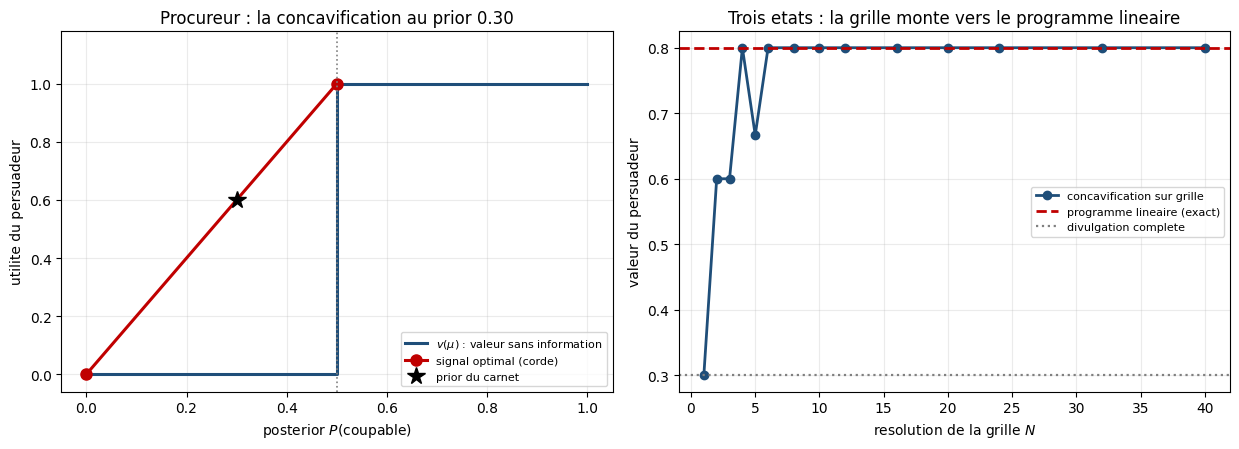

Panneau gauche -- posteriors du signal optimal du procureur :
  posterior [1. 0.] | masse 0.4000 | v = 0.0000
  posterior [0.5 0.5] | masse 0.6000 | v = 1.0000
  la corde au prior 0.30 vaut 0.6000 (sans information : 0.0000)
Panneau droit -- resolution -> valeur :
  N=  1 (   3 points) -> 0.300000 (ecart 5.000e-01)
  N=  2 (   6 points) -> 0.600000 (ecart 2.000e-01)
  N=  3 (  10 points) -> 0.600000 (ecart 2.000e-01)
  N=  4 (  15 points) -> 0.800000 (ecart -1.110e-16)
  N=  5 (  21 points) -> 0.666667 (ecart 1.333e-01)
  N=  6 (  28 points) -> 0.800000 (ecart -1.110e-16)
  N=  8 (  45 points) -> 0.800000 (ecart -1.110e-16)
  N= 10 (  66 points) -> 0.800000 (ecart -1.110e-16)
  N= 12 (  91 points) -> 0.800000 (ecart -1.110e-16)
  N= 16 ( 153 points) -> 0.800000 (ecart -1.110e-16)
  N= 20 ( 231 points) -> 0.800000 (ecart -1.110e-16)
  N= 24 ( 325 points) -> 0.800000 (ecart -1.110e-16)
  N= 32 ( 561 points) -> 0.800000 (ecart -2.220e-16)
  N= 40 ( 861 points) -> 0.800000 (ecart -1.110e-1

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

# --- Panneau gauche : v(mu) du procureur, et le signal optimal comme une corde.
xs = np.linspace(0.0, 1.0, 501)
vs = [valeur_persuadeur(np.array([1.0 - x, x]), u_R_JEU, u_S_PROC) for x in xs]
ax1.step(xs, vs, where="post", color="#1f4e79", lw=2.2,
         label=r"$v(\mu)$ : valeur sans information")

post_proc = posteriors(M1["sol"]["q"])
px = [float(p["posterior"][1]) for p in post_proc]
pv = [valeur_persuadeur(p["posterior"], u_R_JEU, u_S_PROC) for p in post_proc]
ax1.plot(px, pv, "o-", color="#c00000", lw=2.2, ms=8,
         label="signal optimal (corde)")
ax1.axvline(0.5, color="grey", ls=":", lw=1.2)
mu0_proc = INSTANCES["procureur"]["mu0"]
ax1.plot([mu0_proc[1]], [M1["optimal"]], "k*", ms=13, label="prior du carnet")
ax1.set_xlabel(r"posterior $P(\mathrm{coupable})$")
ax1.set_ylabel("utilite du persuadeur")
ax1.set_title("Procureur : la concavification au prior 0.30")
ax1.set_ylim(-0.06, 1.18)
ax1.legend(loc="lower right", fontsize=8)
ax1.grid(alpha=0.25)

# --- Panneau droit : convergence de la grille vers la valeur du programme lineaire.
res = [r for r, _, _, _ in lignes_conv]
val = [v for _, v, _, _ in lignes_conv]
ax2.plot(res, val, "o-", color="#1f4e79", lw=2, ms=6,
         label="concavification sur grille")
ax2.axhline(M3["optimal"], color="#c00000", ls="--", lw=2,
            label="programme lineaire (exact)")
ax2.axhline(M3["divulgation"], color="grey", ls=":", lw=1.6,
            label="divulgation complete")
ax2.set_xlabel("resolution de la grille $N$")
ax2.set_ylabel("valeur du persuadeur")
ax2.set_title("Trois etats : la grille monte vers le programme lineaire")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Les coordonnees des deux panneaux sont imprimees : la figure peut etre verifiee
# sans la regarder, et un ecart entre le trace et la mesure se voit ici.
print("Panneau gauche -- posteriors du signal optimal du procureur :")
for p in post_proc:
    print(f"  posterior {np.round(p['posterior'], 4)} | masse {p['masse']:.4f} | "
          f"v = {valeur_persuadeur(p['posterior'], u_R_JEU, u_S_PROC):.4f}")
print(f"  la corde au prior {mu0_proc[1]:.2f} vaut {M1['optimal']:.4f} "
      f"(sans information : {M1['sans_info']:.4f})")
print("Panneau droit -- resolution -> valeur :")
for n, v, e, k in lignes_conv:
    print(f"  N={n:>3} ({k:>4} points) -> {v:.6f} (ecart {e:.3e})")


### Lecture de la figure

**À gauche**, la fonction $v$ du procureur est une marche d'escalier : $0$ sous le
seuil du juge, $1$ au-dessus. Le point du prior ($0{,}3$) est *sur la marche basse*,
et la corde rouge — le signal optimal — passe au-dessus. La hauteur du point étoilé
est la valeur du persuadeur ; l'écart vertical entre l'étoile et la marche est tout
ce que la persuasion rapporte ici.

**À droite**, la courbe bleue part exactement de la divulgation complète à
$N = 1$ (les sommets du simplexe) et monte vers la ligne rouge du programme
linéaire. Elle ne la franchit jamais. Les paliers visibles sont les résolutions où
le posterior optimal $(5, 2, 1)/8$ tombe juste : l'accord y devient exact, et les
résolutions intermédiaires rappellent que la grille est une restriction, pas une
méthode équivalente.


## 14. Ce que ce carnet établit — et ce qu'il ne prétend pas

**Établi, et falsifiable :**

1. **Les deux méthodes concordent** sur les trois instances, à la tolérance
   déclarée de $10^{-6}$ — et l'accord est *asserté* dans le carnet, pas seulement
   affiché. Le programme linéaire et la concavification ne partagent aucun code :
   l'un optimise sur la loi jointe, l'autre sur les combinaisons convexes d'une
   grille.
2. **La concavification sur grille est une approximation intérieure** : elle ne
   dépasse jamais le programme linéaire — à la tolérance numérique de $10^{-9}$
   près — ce qui est vérifié pour *chaque* résolution de la suite. Sa monotonie est
   **conditionnelle** : vraie le long des chaînes de divisibilité, fausse entre
   résolutions étrangères, et le couple $(4, 5)$ le mesure.
3. **La résolution 1 *est* la divulgation complète** : les sommets du simplexe sont
   les posteriors dégénérés, et l'ancrage est vérifié sur les deux instances où il
   a un sens. C'est ce qui interdit de traiter la méthode B comme une boîte noire.
4. **La persuasion n'est pas la transparence** : sur le procureur et sur les trois
   états, l'optimum dépasse **strictement** la divulgation complète et le signal
   optimal est **non partitionnel** — un même état envoie deux messages distincts.
   Sur le contrôle négatif aux préférences alignées, l'optimum **est** la
   divulgation complète et le signal optimal est partitionnel.
5. **La contrainte d'incitation est saturée à l'optimum** de l'instance à trois
   états : le persuadeur pousse le receveur jusqu'à l'indifférence, pas au-delà.

**Ce que le carnet ne fait pas** — des extensions, pas des oublis : pas de
persuasion **dynamique** (le persuadeur ne révèle qu'une fois), pas de **plusieurs
receveurs** (pas de jeu entre eux), pas de contrainte de crédibilité *ex post*
(le signal est engageant par hypothèse), pas de **vérifiabilité partielle** des
messages, pas de coût d'acquisition d'information. Chacune de ces variantes change
la formulation — et la concavification y survit rarement telle quelle.


## 15. Références

- **Kamenica, E. (2019).** *Bayesian Persuasion and Information Design.* Annual
  Review of Economics, 11, 249–272. — le cadre, la formulation par concavification
  et la lecture de la grille comme l'enveloppe concave de $v$.
- **Kamenica, E., & Gentzkow, M. (2011).** *Bayesian Persuasion.* American
  Economic Review, 101(6), 2590–2615. — l'article fondateur, et l'instance
  procureur / juge reprise ici.
- **Aumann, R. J., & Maschler, M. (1995).** *Repeated Games with Incomplete
  Information.* MIT Press. — la formulation de la loi jointe « état × message »
  qui rend le problème linéaire, et le principe de révélation utilisé en méthode A.

Ces trois références ne sont pas incluses dans le dépôt (droits d'édition) ; elles
sont citées, et la formulation du programme linéaire est une reconstitution
classique, pas une copie de code.
